In [1]:
import pandas as pd
from statsbombpy import sb
df_raw = sb.events(match_id= 3869685)

c:\Users\pawan\anaconda34\envs\dataAnalysisPython\lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


In [2]:
import math

In [3]:
df = df_raw.copy(deep = True)

In [4]:
from mplsoccer import VerticalPitch

In [6]:
df[['x', 'y']] = df['location'].apply(pd.Series)

df = df[df['team'] == 'Argentina']

In [7]:
df.head()

,50_50,bad_behaviour_card,ball_receipt_outcome,ball_recovery_offensive,ball_recovery_recovery_failure,block_deflection,block_offensive,carry_end_location,clearance_aerial_won,clearance_body_part,...,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,x,y
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,"{'formation': 433, 'lineup': [{'player': {'id'...",Argentina,779,00:00:00.000,Starting XI,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Argentina,779,00:00:00.000,Half Start,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Argentina,779,00:00:00.000,Half Start,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Argentina,779,00:00:00.000,Half Start,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Argentina,779,00:00:00.000,Half Start,NaN,NaN,NaN


In [8]:
df[['minute', 'second']]

,minute,second
0,0,0
3,0,0
5,45,0
7,90,0
9,105,0
...,...,...
4398,98,37
4399,106,4
4402,124,7
4404,125,58


In [9]:
df['newsecond'] = 60 * df['minute'] + df['second']

C:\Users\pawan\AppData\Local\Temp\ipykernel_8440\3932970669.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['newsecond'] = 60 * df['minute'] + df['second']


In [10]:
df = df.sort_values(by = ['newsecond'])

In [11]:
df['newsecond']

0          0
3          0
14        16
2390      17
1277      17
        ... 
4242    7456
4406    7497
4287    7510
4244    7557
4404    7558
Name: newsecond, Length: 2372, dtype: int64

In [12]:
df['passer'] = df['player_id']

df['recipient'] = df['passer'].shift(-1)

In [13]:
passes_df = df[df['type'] == 'Pass']

In [14]:
passes_df['pass_outcome']

14             NaN
15             NaN
16             NaN
17             NaN
18             NaN
           ...    
1268           NaN
1269           NaN
1270           NaN
1272    Incomplete
1273           NaN
Name: pass_outcome, Length: 693, dtype: object

In [15]:
passes_df['pass_outcome'] = passes_df['pass_outcome'].fillna('Successful')

C:\Users\pawan\AppData\Local\Temp\ipykernel_8440\301206241.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passes_df['pass_outcome'] = passes_df['pass_outcome'].fillna('Successful')


In [16]:
passes_df['pass_outcome']

14      Successful
15      Successful
16      Successful
17      Successful
18      Successful
           ...    
1268    Successful
1269    Successful
1270    Successful
1272    Incomplete
1273    Successful
Name: pass_outcome, Length: 693, dtype: object

In [17]:
completions = passes_df[passes_df['pass_outcome'] == 'Successful']

In [18]:
sub_df = df[df['type'] == 'Substitution']

first_sub = sub_df['newsecond'].min()

In [19]:
first_sub

3831

In [20]:
if first_sub < (60 * 45):
    first_sub = 60*45

In [21]:
completions = completions[completions['newsecond'] < first_sub]

In [22]:
completions.shape

(317, 99)

In [23]:
avg_locs_and_count = completions.groupby('passer').agg({'x' : ['mean'], 'y' : ['mean', 'count']})

In [25]:
avg_locs_and_count.columns = ['x', 'y', 'count']

In [26]:
avg_locs_and_count

,x,y,count
passer,,,
2995.0,79.884000,11.448000,25
3090.0,38.279545,23.350000,44
5503.0,71.588889,51.096296,27
5507.0,58.567857,7.335714,28
6909.0,12.641667,43.966667,12
7797.0,59.159459,59.248649,37
20572.0,33.905128,53.346154,39
27886.0,68.737500,23.845833,24
29201.0,59.414286,72.085714,28


In [27]:
passes_btwn = completions.groupby(['passer', 'recipient']).id.count().reset_index()

In [28]:
passes_btwn.rename({'id' : 'pass_count'}, axis = 'columns', inplace= True)

In [29]:
passes_btwn

,passer,recipient,pass_count
0,2995.0,2995.0,3
1,2995.0,3090.0,3
2,2995.0,5503.0,3
3,2995.0,5507.0,4
4,2995.0,7797.0,3
...,...,...,...
80,38718.0,20572.0,6
81,38718.0,27886.0,3
82,38718.0,29201.0,6
83,38718.0,29560.0,1


In [30]:
passes_btwn = passes_btwn.merge(avg_locs_and_count, left_on= 'passer', right_index=True)

passes_btwn = passes_btwn.merge(avg_locs_and_count, left_on = 'recipient', right_index= True, suffixes= ['', '_end'])

In [31]:
passes_btwn

,passer,recipient,pass_count,x,y,count,x_end,y_end,count_end
0,2995.0,2995.0,3,79.884,11.4480,25,79.884000,11.448000,25
1,2995.0,3090.0,3,79.884,11.4480,25,38.279545,23.350000,44
2,2995.0,5503.0,3,79.884,11.4480,25,71.588889,51.096296,27
3,2995.0,5507.0,4,79.884,11.4480,25,58.567857,7.335714,28
4,2995.0,7797.0,3,79.884,11.4480,25,59.159459,59.248649,37
...,...,...,...,...,...,...,...,...,...
80,38718.0,20572.0,6,56.135,36.5325,40,33.905128,53.346154,39
81,38718.0,27886.0,3,56.135,36.5325,40,68.737500,23.845833,24
82,38718.0,29201.0,6,56.135,36.5325,40,59.414286,72.085714,28
83,38718.0,29560.0,1,56.135,36.5325,40,76.346154,37.538462,13


In [32]:
passes_btwn = passes_btwn[passes_btwn['pass_count'] >= 4]

In [33]:
def pass_line_template(ax, x, y, end_x, end_y, line_color):

    ax.annotate(
        '',
        xy = (end_y, end_x),
        xytext = (y, x),
        zorder = 1,
        arrowprops= dict(arrowstyle='-|>', linewidth= 4, color = line_color, alpha= .85)
    )

def pass_line_template_shrink(ax, x, y, end_x, end_y, line_color, dist_delta= 1.2):
    dist = math.hypot(end_x - x, end_y - y)
    angle = math.atan2(end_y-y, end_x-x)
    upd_x = x + (dist - dist_delta) * math.cos(angle)
    upd_y = y + (dist - dist_delta) * math.sin(angle)


    pass_line_template(ax, x, y, upd_x, upd_y, line_color = line_color)


Text(0.5, 0.94, 'Node Size = Pass Involvement | Line Width = Pass Volume')

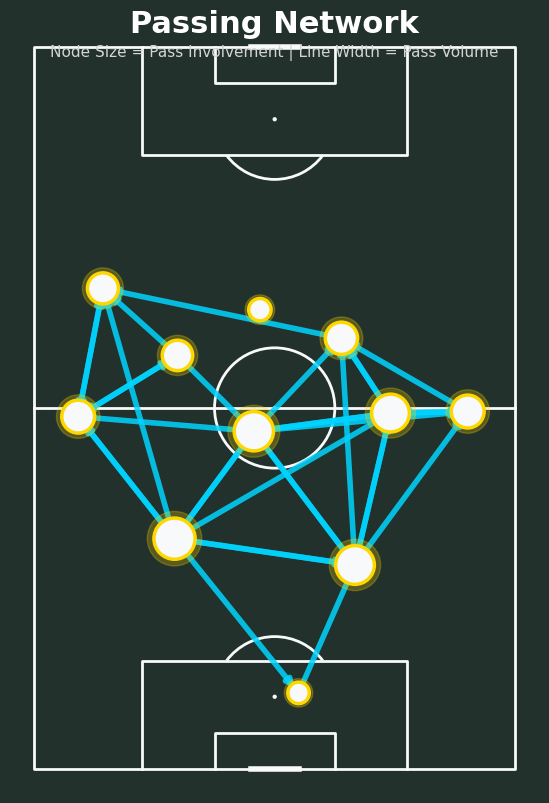

In [40]:
# ---------------------------
pitch = VerticalPitch(
    pitch_type='statsbomb',
    pitch_color='#22312B',
    line_color='#F8F9FA',
    linewidth=2
)

fig, ax = pitch.draw(figsize=(12, 8))

fig.set_facecolor('#22312B')

# ---------------------------
# Pass Connections
# ---------------------------
max_passes = passes_btwn['pass_count'].max()

for _, row in passes_btwn.iterrows():

    alpha = row['pass_count'] / max_passes

    pass_line_template_shrink(
        ax=ax,
        x=row['x'],
        y=row['y'],
        end_x=row['x_end'],
        end_y=row['y_end'],
        line_color='#00D4FF',
        dist_delta=0.15 + alpha * 0.85,
    )

# ---------------------------
# Glow Layer
# ---------------------------
pitch.scatter(
    avg_locs_and_count.x,
    avg_locs_and_count.y,
    s=avg_locs_and_count['count'] * 35,
    color='#FFD700',
    alpha=0.25,
    ax=ax,
    zorder=1
)

# ---------------------------
# Main Nodes
# ---------------------------
pitch.scatter(
    avg_locs_and_count.x,
    avg_locs_and_count.y,
    s=avg_locs_and_count['count'] * 20,
    color='#F8F9FA',
    edgecolors='#FFD700',
    linewidth=2.5,
    ax=ax,
    zorder=3
)

# ---------------------------
# Title
# ---------------------------
fig.text(
    0.5,
    0.97,
    'Passing Network',
    color='white',
    fontsize=22,
    fontweight='bold',
    ha='center'
)

fig.text(
    0.5,
    0.94,
    'Node Size = Pass Involvement | Line Width = Pass Volume',
    color='#D3D3D3',
    fontsize=11,
    ha='center'
)
